<a href="https://colab.research.google.com/github/sonia-rafique/Internship-DataScience-Tasks./blob/main/BANK_MARKETING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, roc_curve, precision_recall_curve)
from category_encoders import TargetEncoder

# Set plot styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('bank.csv', sep=';')
print(f"Dataset Shape: {df.shape}")
print(df.info())

Dataset Shape: (4521, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB
None


In [4]:
# 1. Cyclical Feature Engineering for Months
month_map = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6,
             'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}
df['month_num'] = df['month'].map(month_map)

# Map to coordinates on a 2D circle
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
df.drop(['month', 'month_num'], axis=1, inplace=True)

# 2. Convert Target to Binary
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# 3. Stratified Train-Test Split (Crucial for imbalanced data)
X = df.drop('y', axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Advanced Target Encoding for High-Cardinality Variables
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
encoder = TargetEncoder(cols=cat_cols, smoothing=15.0)

X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)


/tmp/ipykernel_2675/2886927821.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_2675/2886927821.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Declined (0)', 'Subscribed (1)'])
/tmp/ipykernel_2675/2886927821.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='y', y='duration', ax=axes[1], palette=['#4C72B0', '#C44E52'], inner="quartile")
/tmp/ipykernel_2675/2886927821.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a F

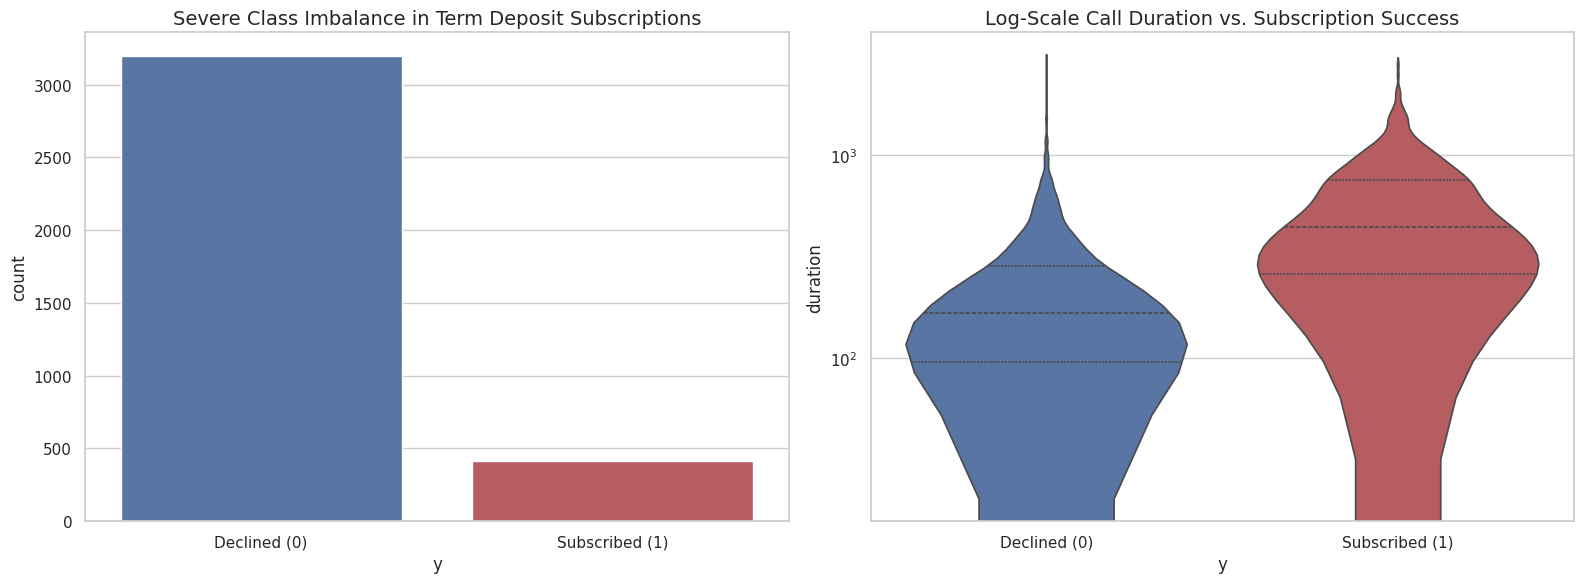

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Target Class Imbalance
sns.countplot(x=y_train, ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Severe Class Imbalance in Term Deposit Subscriptions', fontsize=14)
axes[0].set_xticklabels(['Declined (0)', 'Subscribed (1)'])

# Plot 2: Violin Plot of Call Duration vs Target
sns.violinplot(data=df, x='y', y='duration', ax=axes[1], palette=['#4C72B0', '#C44E52'], inner="quartile")
axes[1].set_yscale('log') # Log scale handles the massive outliers gracefully
axes[1].set_title('Log-Scale Call Duration vs. Subscription Success', fontsize=14)
axes[1].set_xticklabels(['Declined (0)', 'Subscribed (1)'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_2675/1380972194.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train,palette=pink,width=0.45,edgecolor="#8E4963",linewidth=1.2,ax=ax[0])
/tmp/ipykernel_2675/1380972194.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Declined','Subscribed'],fontsize=8,fontweight='bold')
/tmp/ipykernel_2675/1380972194.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x='y',y='duration',palette=pink,inner=None,
/tmp/ipykernel_2675/1380972194.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using

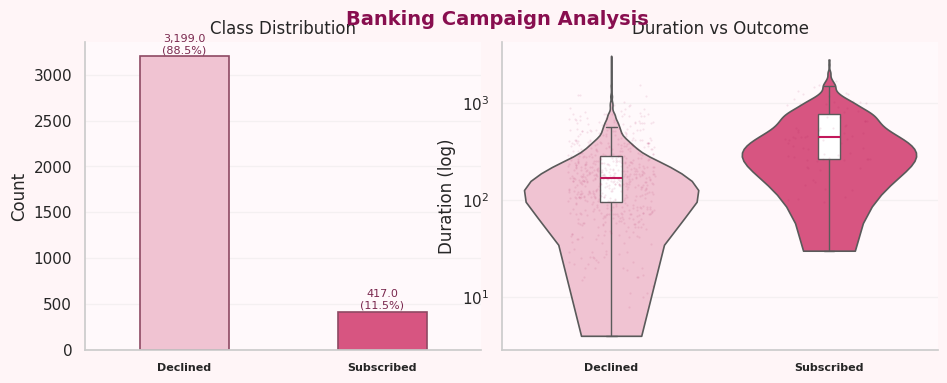

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pink=["#F8BBD0","#EC407A"]; bg="#FFF5F7"

fig,ax=plt.subplots(1,2,figsize=(11,4),gridspec_kw={'wspace':0.05,'width_ratios':[1,1.1]})
fig.patch.set_facecolor(bg)

sns.countplot(x=y_train,palette=pink,width=0.45,edgecolor="#8E4963",linewidth=1.2,ax=ax[0])

total=len(y_train)

for p in ax[0].patches:
    h=p.get_height()
    ax[0].annotate(f'{h:,}\n({100*h/total:.1f}%)',(p.get_x()+p.get_width()/2,h),
                   ha='center',fontsize=8,color='#7A284E',xytext=(0,2),
                   textcoords='offset points')

ax[0].set(title='Class Distribution',xlabel='',ylabel='Count')
ax[0].set_xticklabels(['Declined','Subscribed'],fontsize=8,fontweight='bold')
ax[0].grid(axis='y',alpha=0.2)
ax[0].set_facecolor("#FFF9FB")

sns.violinplot(data=df,x='y',y='duration',palette=pink,inner=None,
               linewidth=1.2,cut=0,ax=ax[1])

sns.boxplot(data=df,x='y',y='duration',width=0.1,showfliers=False,
            boxprops={'facecolor':'white'},
            medianprops={'color':'#C2185B','linewidth':1.5},ax=ax[1])

sns.stripplot(data=df.sample(min(700,len(df))),x='y',y='duration',
              color='#AD1457',alpha=0.1,size=1.5,jitter=0.2,ax=ax[1])

ax[1].set_yscale('log')
ax[1].set(title='Duration vs Outcome',xlabel='',ylabel='Duration (log)')
ax[1].set_xticklabels(['Declined','Subscribed'],fontsize=8,fontweight='bold')
ax[1].grid(axis='y',alpha=0.2)
ax[1].set_facecolor("#FFF9FB")

sns.despine()

fig.suptitle('Banking Campaign Analysis',fontsize=14,fontweight='bold',
             color='#880E4F',y=0.96)

plt.tight_layout(pad=0.3)
plt.show()

In [11]:
# Calculate balance factor dynamically
imbalance_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialize highly optimized gradient boosting model
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.015,
    scale_pos_weight=imbalance_ratio, # Forces cost-sensitive mathematical focus
    num_leaves=31,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train with early stopping to prevent overtraining
lgb_model.fit(
    X_train_encoded, y_train,
    eval_set=[(X_test_encoded, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

[LightGBM] [Info] Number of positive: 417, number of negative: 3199
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000605 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 930
[LightGBM] [Info] Number of data points in the train set: 3616, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.115321 -> initscore=-2.037507
[LightGBM] [Info] Start training from score -2.037507
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.015, max_depth=6,
               n_estimators=1000, n_jobs=-1, random_state=42,
               scale_pos_weight=7.671462829736211, subsample=0.8)

============= PRODUCTION METRICS REPORT =============
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       801
           1       0.55      0.06      0.10       104

    accuracy                           0.89       905
   macro avg       0.72      0.53      0.52       905
weighted avg       0.85      0.89      0.84       905



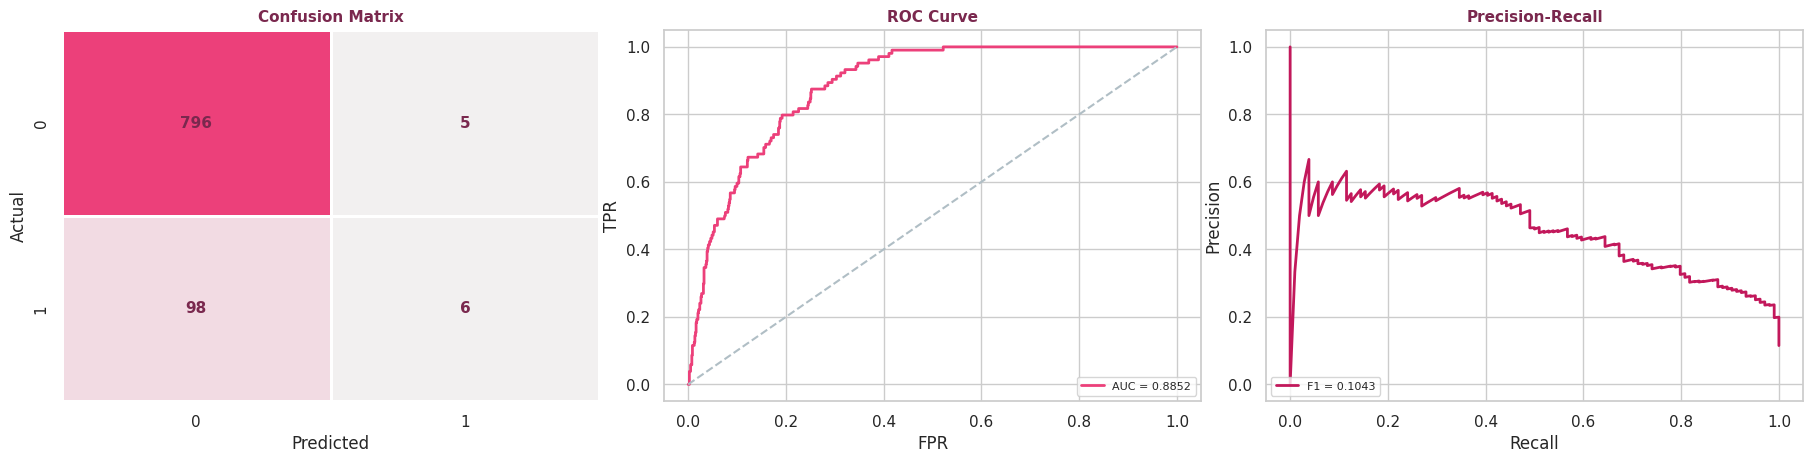

In [13]:
y_pred=lgb_model.predict(X_test_encoded); y_prob=lgb_model.predict_proba(X_test_encoded)[:,1]

print("============= PRODUCTION METRICS REPORT =============")
print(classification_report(y_test,y_pred))

fig,axes=plt.subplots(1,3,figsize=(18,4.5))

cm=confusion_matrix(y_test,y_pred)
pink_cmap=sns.light_palette("#EC407A",as_cmap=True)

sns.heatmap(cm,annot=True,fmt='d',cmap=pink_cmap,ax=axes[0],cbar=False,
            linewidths=1,linecolor='white',
            annot_kws={"fontsize":11,"fontweight":"bold","color":"#7A284E"})

axes[0].set_title('Confusion Matrix',fontsize=11,fontweight='bold',color='#7A284E')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr,tpr,_=roc_curve(y_test,y_prob)

axes[1].plot(fpr,tpr,label=f'AUC = {roc_auc_score(y_test,y_prob):.4f}',
             color='#EC407A',lw=2)

axes[1].plot([0,1],[0,1],linestyle='--',color='#B0BEC5')

axes[1].set_title('ROC Curve',fontsize=11,fontweight='bold',color='#7A284E')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right',fontsize=8)

precision,recall,_=precision_recall_curve(y_test,y_prob)

axes[2].plot(recall,precision,
             label=f'F1 = {f1_score(y_test,y_pred):.4f}',
             color='#C2185B',lw=2)

axes[2].set_title('Precision-Recall',fontsize=11,fontweight='bold',color='#7A284E')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left',fontsize=8)

plt.tight_layout(pad=0.2)
plt.show()

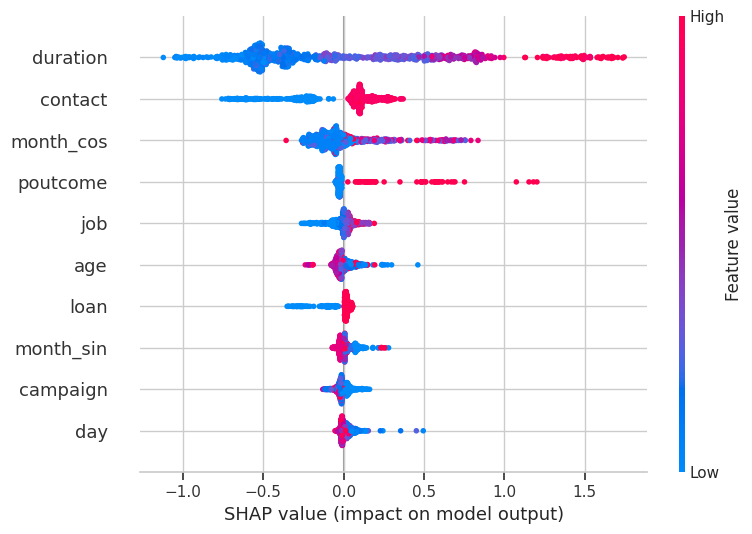

In [14]:
# Initialize tree explainer
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_test_encoded)

# Global Interpretability Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_encoded, max_display=10)


>>> Deep-Dive Audit: Customer Profile #1 <<<


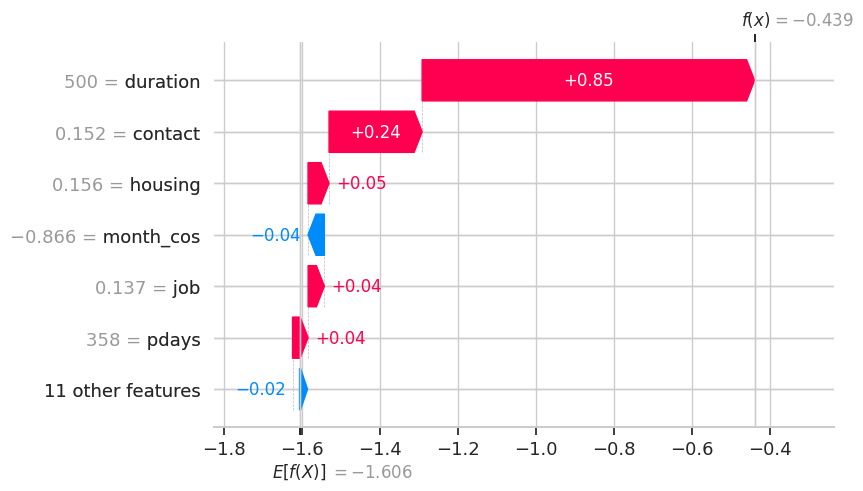


>>> Deep-Dive Audit: Customer Profile #2 <<<


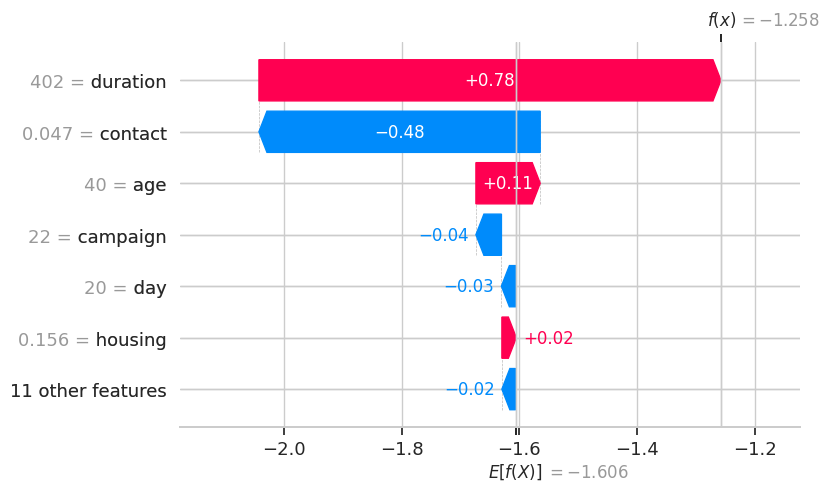


>>> Deep-Dive Audit: Customer Profile #3 <<<


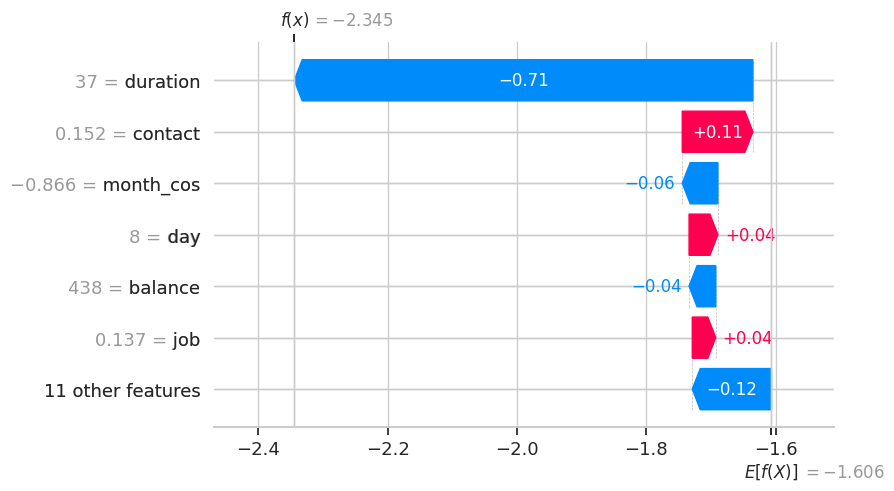


>>> Deep-Dive Audit: Customer Profile #4 <<<


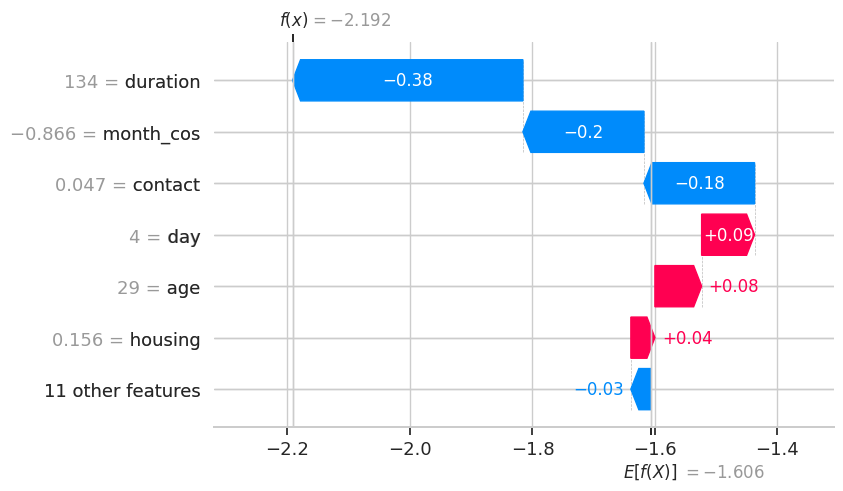


>>> Deep-Dive Audit: Customer Profile #5 <<<


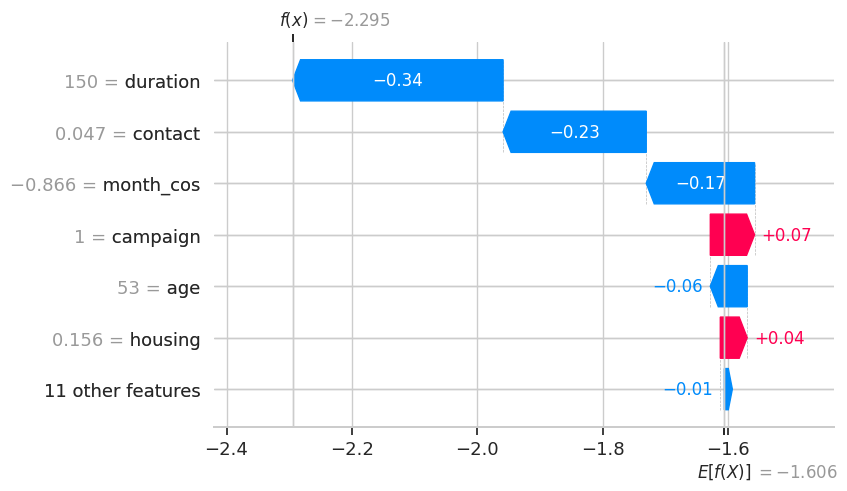

In [15]:
for idx in range(5):
    print(f"\n>>> Deep-Dive Audit: Customer Profile #{idx + 1} <<<")
    plt.figure()
    # Build local decision waterfall graph for the selected instance
    shap.plots.waterfall(shap_values[idx], max_display=7)
    plt.show()